# Customer Intent Intelligence
## Notebook 01 — Data Exploration & NLP Preprocessing

### Objective

This notebook performs the initial data understanding and NLP preprocessing
for the BANKING77 customer intent classification dataset.

The notebook covers:

1. Dataset loading
2. Dataset validation
3. Exploratory data analysis
4. Intent distribution analysis
5. Text-length analysis
6. Vocabulary and n-gram exploration
7. NLP preprocessing
8. Comparison of raw and processed text
9. Saving processed datasets


## 1. Import Required Libraries


In [1]:
import os
import re
import sys

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

from sklearn.feature_extraction.text import CountVectorizer

# The canonical preprocessing function lives in src/preprocessing.py so that
# this notebook and the inference layer cannot drift apart.
sys.path.insert(0, os.path.abspath("../src"))
from preprocessing import preprocess_text

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1006)>


[nltk_data] Error loading punkt_tab: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1006)>


## 2. Load BANKING77

BANKING77 contains customer-service queries assigned to 77 fine-grained
customer intents.

The dataset already provides separate training and testing files.

In [2]:
RAW_DIR = "../data/raw/banking77"

train_url = (
    "https://raw.githubusercontent.com/"
    "PolyAI-LDN/task-specific-datasets/"
    "master/banking_data/train.csv"
)

test_url = (
    "https://raw.githubusercontent.com/"
    "PolyAI-LDN/task-specific-datasets/"
    "master/banking_data/test.csv"
)

# Use the local copy if the dataset has already been downloaded, so re-running
# this notebook does not depend on network access.
if os.path.exists(f"{RAW_DIR}/train.csv"):

    train_df = pd.read_csv(f"{RAW_DIR}/train.csv")
    test_df = pd.read_csv(f"{RAW_DIR}/test.csv")

    print("Loaded BANKING77 from local cache.")

else:

    train_df = pd.read_csv(train_url)
    test_df = pd.read_csv(test_url)

    print("Downloaded BANKING77 from source.")

Loaded BANKING77 from local cache.


In [3]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (10003, 2)
Test shape: (3080, 2)


In [4]:
train_df.head()


,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived after 2 weeks?,card_arrival
2,I have been waiting over a week. Is the card still coming?,card_arrival
3,Can I track my card while it is in the process of delivery?,card_arrival
4,"How do I know if I will get my card, or if it is lost?",card_arrival


In [5]:
test_df.head()

,text,category
0,How do I locate my card?,card_arrival
1,"I still have not received my new card, I ordered over a week ago.",card_arrival
2,I ordered a card but it has not arrived. Help please!,card_arrival
3,Is there a way to know when my card will arrive?,card_arrival
4,My card has not arrived yet.,card_arrival


In [6]:
os.makedirs(RAW_DIR, exist_ok=True)

train_df.to_csv(
    f"{RAW_DIR}/train.csv",
    index=False
)

test_df.to_csv(
    f"{RAW_DIR}/test.csv",
    index=False
)

In [7]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nColumns:")
print(train_df.columns.tolist())

print("\nNumber of intents:")
print(train_df["category"].nunique())

print("\nFirst 5 rows:")
display(train_df.head())

Train shape: (10003, 2)
Test shape: (3080, 2)

Columns:
['text', 'category']

Number of intents:
77

First 5 rows:


,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived after 2 weeks?,card_arrival
2,I have been waiting over a week. Is the card still coming?,card_arrival
3,Can I track my card while it is in the process of delivery?,card_arrival
4,"How do I know if I will get my card, or if it is lost?",card_arrival


## 3. Dataset Overview

### a) Basic EDA

In [8]:
train_df = pd.read_csv(f"{RAW_DIR}/train.csv")
test_df = pd.read_csv(f"{RAW_DIR}/test.csv")

In [9]:
print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

Training shape: (10003, 2)
Testing shape: (3080, 2)


In [10]:
print("\nTraining columns:")
print(train_df.columns.tolist())

print("\nTesting columns:")
print(test_df.columns.tolist())


Training columns:
['text', 'category']

Testing columns:
['text', 'category']


In [11]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   text      10003 non-null  str  
 1   category  10003 non-null  str  
dtypes: str(2)
memory usage: 943.8 KB


## 5. Target Variable

The `category` column contains the customer intent.

BANKING77 contains 77 fine-grained intents.

In [12]:
print("Number of unique intents:", train_df["category"].nunique())

Number of unique intents: 77


In [13]:
intent_names = sorted(train_df["category"].unique())

print("Number of intents:", len(intent_names))
print("\nIntent names:")
for intent in intent_names:
    print(intent)

Number of intents: 77

Intent names:
Refund_not_showing_up
activate_my_card
age_limit
apple_pay_or_google_pay
atm_support
automatic_top_up
balance_not_updated_after_bank_transfer
balance_not_updated_after_cheque_or_cash_deposit
beneficiary_not_allowed
cancel_transfer
card_about_to_expire
card_acceptance
card_arrival
card_delivery_estimate
card_linking
card_not_working
card_payment_fee_charged
card_payment_not_recognised
card_payment_wrong_exchange_rate
card_swallowed
cash_withdrawal_charge
cash_withdrawal_not_recognised
change_pin
compromised_card
contactless_not_working
country_support
declined_card_payment
declined_cash_withdrawal
declined_transfer
direct_debit_payment_not_recognised
disposable_card_limits
edit_personal_details
exchange_charge
exchange_rate
exchange_via_app
extra_charge_on_statement
failed_transfer
fiat_currency_support
get_disposable_virtual_card
get_physical_card
getting_spare_card
getting_virtual_card
lost_or_stolen_card
lost_or_stolen_phone
order_physical_card
pa

## 6. EDA Analysis


In [14]:
print("Training missing values:")
print(train_df.isnull().sum())

print("\nTesting missing values:")
print(test_df.isnull().sum())

Training missing values:
text        0
category    0
dtype: int64

Testing missing values:
text        0
category    0
dtype: int64


In [15]:
print("Duplicate training rows:",
      train_df.duplicated().sum())

print("Duplicate testing rows:",
      test_df.duplicated().sum())

Duplicate training rows: 0
Duplicate testing rows: 0


In [16]:
print("Duplicate training texts:",
      train_df["text"].duplicated().sum())

print("Duplicate testing texts:",
      test_df["text"].duplicated().sum())

Duplicate training texts: 0
Duplicate testing texts: 0


In [17]:
#Cross-dataset duplicate check
train_texts = set(train_df["text"])

cross_duplicates = test_df["text"].isin(train_texts).sum()

print("Test queries also appearing in training:",
      cross_duplicates)

Test queries also appearing in training: 0


## 7. Intent Distribution


In [18]:
intent_counts = train_df["category"].value_counts()

intent_counts.head()

category
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
Name: count, dtype: int64

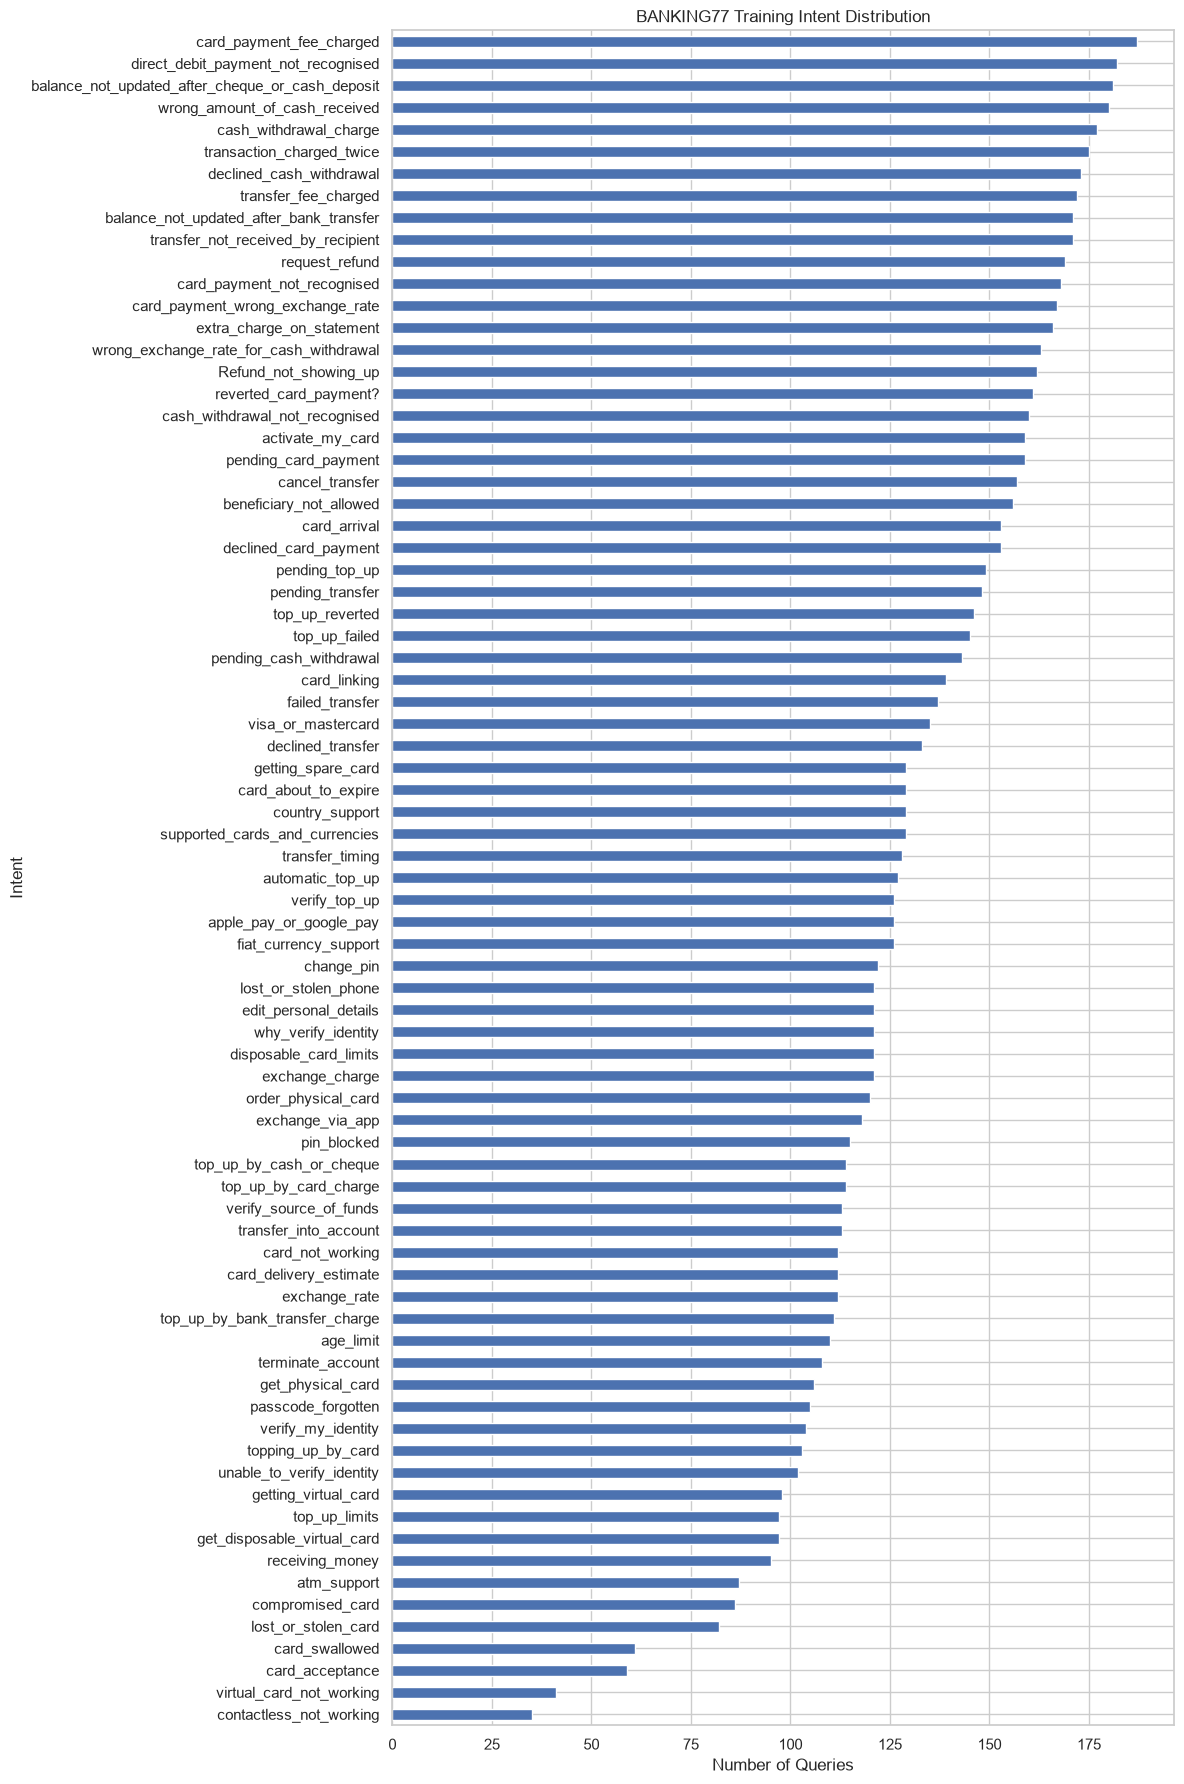

In [19]:
plt.figure(figsize=(12, 18))

intent_counts.sort_values().plot(
    kind="barh"
)

plt.title("BANKING77 Training Intent Distribution")
plt.xlabel("Number of Queries")
plt.ylabel("Intent")

plt.tight_layout()
plt.show()

In [20]:
print("Top 10 most frequent intents:")
display(intent_counts.head(10))

Top 10 most frequent intents:


category
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
transaction_charged_twice                           175
declined_cash_withdrawal                            173
transfer_fee_charged                                172
transfer_not_received_by_recipient                  171
balance_not_updated_after_bank_transfer             171
Name: count, dtype: int64

In [21]:
print("10 least frequent intents:")
display(intent_counts.tail(10))

10 least frequent intents:


category
top_up_limits                  97
get_disposable_virtual_card    97
receiving_money                95
atm_support                    87
compromised_card               86
lost_or_stolen_card            82
card_swallowed                 61
card_acceptance                59
virtual_card_not_working       41
contactless_not_working        35
Name: count, dtype: int64

In [22]:
#Class imbalance statistics

print("Maximum class size:", intent_counts.max())
print("Minimum class size:", intent_counts.min())

imbalance_ratio = intent_counts.max() / intent_counts.min()

print("Max / Min class ratio:",
      round(imbalance_ratio, 2))

Maximum class size: 187
Minimum class size: 35
Max / Min class ratio: 5.34


## 8. Text Statistics

Customer queries vary in length.

We examine:

- Character count
- Word count
- Mean length
- Median length
- Minimum length
- Maximum length

In [23]:
train_df["char_count"] = train_df["text"].str.len()

train_df["word_count"] = (
    train_df["text"]
    .str.split()
    .str.len()
)

In [24]:
train_df['char_count']

0        30
1        60
2        58
3        59
4        54
         ..
9998     38
9999     34
10000    35
10001    30
10002    32
Name: char_count, Length: 10003, dtype: int64

In [25]:
train_df['word_count']

0         7
1        13
2        12
3        13
4        15
         ..
9998      6
9999      5
10000     5
10001     6
10002     4
Name: word_count, Length: 10003, dtype: int64

In [26]:
train_df[["char_count", "word_count"]].describe()

,char_count,word_count
count,10003.000000,10003.000000
mean,59.473758,11.949415
std,40.867901,7.891577
min,13.000000,2.000000
25%,36.000000,7.000000
50%,47.000000,10.000000
75%,64.000000,13.000000
max,433.000000,79.000000


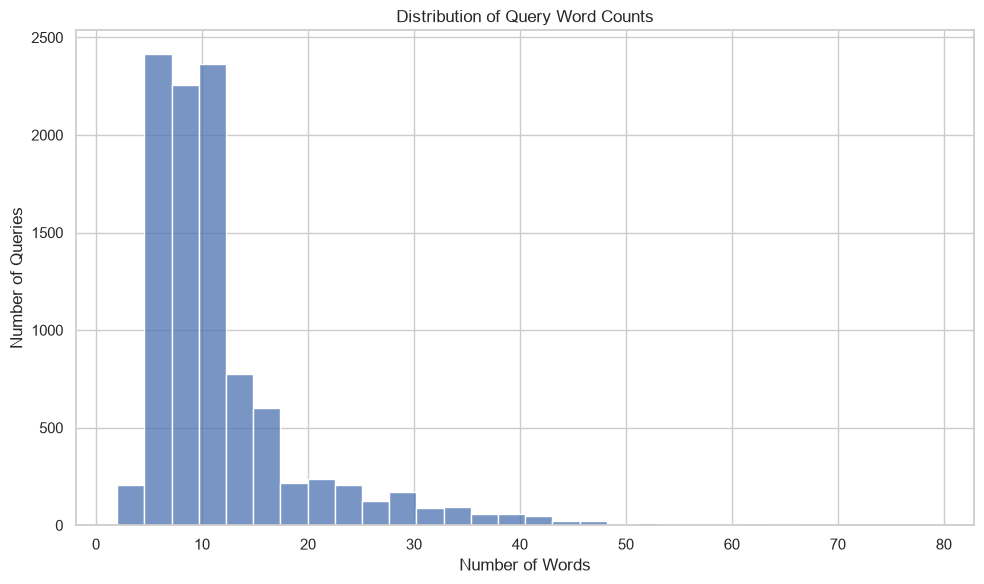

In [27]:
# Text length distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    train_df["word_count"],
    bins=30
)

plt.title("Distribution of Query Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Number of Queries")

plt.tight_layout()
plt.show()

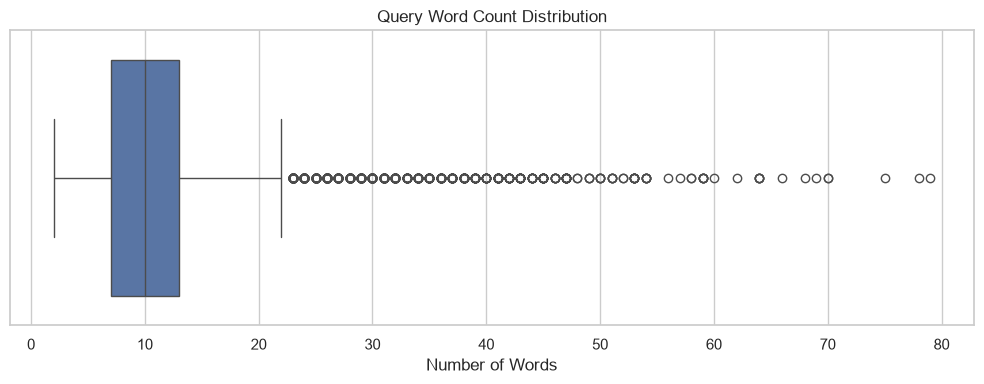

In [28]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=train_df["word_count"]
)

plt.title("Query Word Count Distribution")
plt.xlabel("Number of Words")

plt.tight_layout()
plt.show()

Shortest and longest queries

In [29]:
shortest_idx = train_df["word_count"].idxmin()

print("Shortest query:")
print(train_df.loc[shortest_idx, "text"])

print("\nIntent:")
print(train_df.loc[shortest_idx, "category"])

Shortest query:
Cancel Transaction

Intent:
cancel_transfer


In [30]:
longest_idx = train_df["word_count"].idxmax()

print("Longest query:")
print(train_df.loc[longest_idx, "text"])

print("\nIntent:")
print(train_df.loc[longest_idx, "category"])

Longest query:
Hearing back from us regarding your important verification results may take 10 minutes to one hour time.  If verification results do fail, double-check to make sure all of your images are clear --  make sure your photos have no glare or blurring. Note: These photos need to be readable as well.  You also need to be 18 years of age or older.  You must be a resident of Switzerland or the European Economic Area to open a new account.

Intent:
unable_to_verify_identity


### Intent vs text length

In [31]:
intent_length = (
    train_df
    .groupby("category")["word_count"]
    .agg(["mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

intent_length.head(10)

,mean,median,min,max
category,,,,
transfer_not_received_by_recipient,17.549708,12.0,4,58
transfer_fee_charged,17.395349,11.0,4,78
pending_cash_withdrawal,16.531469,11.0,3,64
failed_transfer,15.992701,10.0,3,54
direct_debit_payment_not_recognised,15.989011,12.0,3,58
transaction_charged_twice,15.988571,10.0,4,66
Refund_not_showing_up,15.808642,10.0,4,50
wrong_exchange_rate_for_cash_withdrawal,15.460123,12.0,5,39
cash_withdrawal_not_recognised,15.437500,12.0,4,40


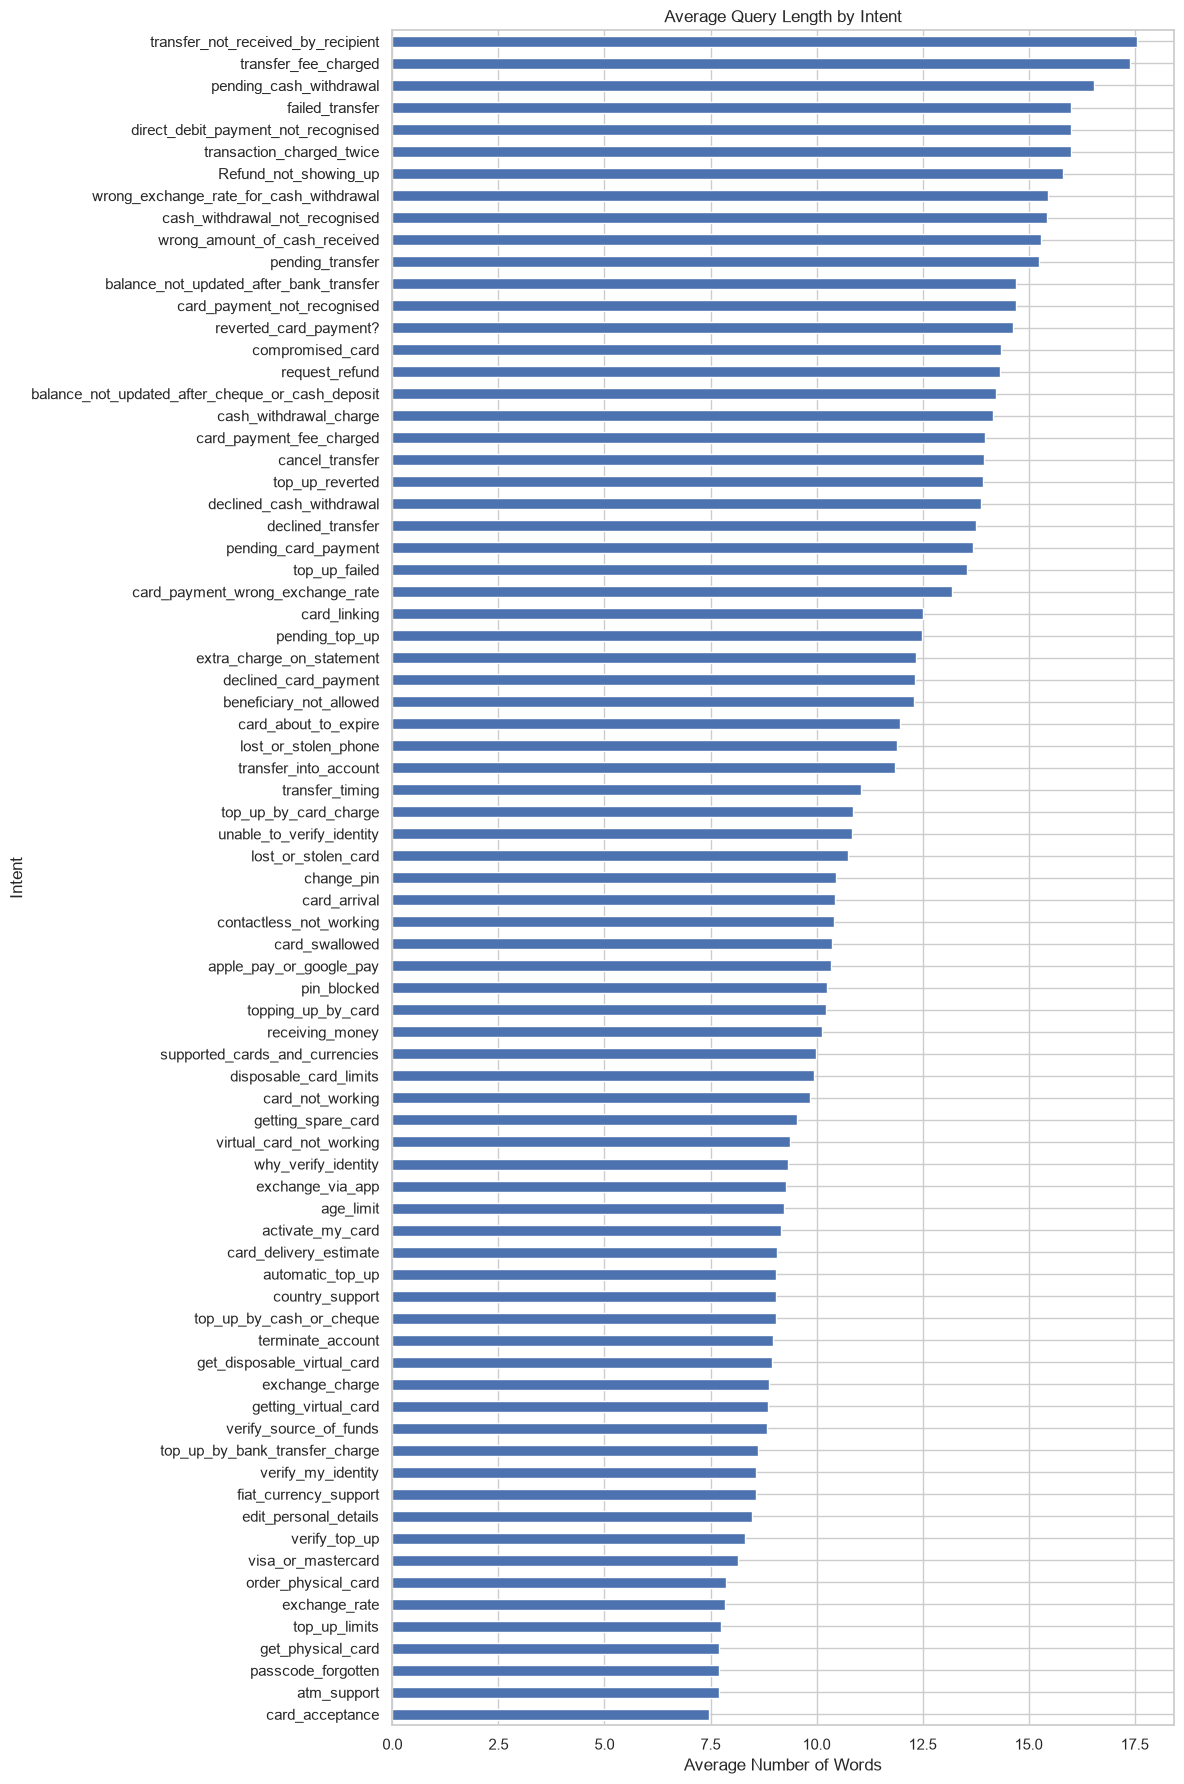

In [32]:
plt.figure(figsize=(12, 18))

intent_length["mean"].sort_values().plot(
    kind="barh"
)

plt.title("Average Query Length by Intent")
plt.xlabel("Average Number of Words")
plt.ylabel("Intent")

plt.tight_layout()
plt.show()

## 9. Inspect Customer Queries

Numerical statistics do not show the semantic differences between intents.

We therefore inspect actual examples from selected intents, particularly
intents that may have similar meanings.

In [33]:
def show_intent_examples(intent, n=10):
    return (
        train_df[train_df["category"] == intent]
        [["text", "category"]]
        .sample(min(n, len(train_df[train_df["category"] == intent])),
                random_state=42)
    )

In [34]:
show_intent_examples("card_arrival")

,text,category
84,"If I ordered my new card last week, how much longer should I wait to receive it?",card_arrival
86,Where is my new card if I haven't received it yet?,card_arrival
97,Is there a reason my new card hasn't arrived?,card_arrival
115,Do you have a tracking number for the card I was sent?,card_arrival
29,What is the expected delivery date for my card?,card_arrival
114,I still haven't gotten my new card. When will it get here?,card_arrival
78,My card hasn't arrived in the mail yet. I ordered it two weeks ago. What can I do?,card_arrival
81,"I've been waiting a while for my card, is there a way to know when it will arrive?",card_arrival
18,My new card has not been delivered to my home yet. What is going on?,card_arrival
15,Will I be able to track the card that was sent to me?,card_arrival


In [35]:
show_intent_examples("card_delivery_estimate")

,text,category
1046,When will my card come? I need it as soon as possible!,card_delivery_estimate
1071,Send me my card now! ASAP,card_delivery_estimate
1010,Can I get my card fast tracked?,card_delivery_estimate
1053,How long will it take to have my card mailed to me?,card_delivery_estimate
1048,What is the wait time for delivery to the US?,card_delivery_estimate
1075,When will it get delivered?,card_delivery_estimate
1032,How long will this take to get to me?,card_delivery_estimate
1017,"i am express delivering my card to the us, how long will that take",card_delivery_estimate
1016,Can I have it delivered on a specific date?,card_delivery_estimate
1050,When can I expect my card to arrive?,card_delivery_estimate


## 10. NLP preprocessing

The preprocessing pipeline consists of:

1. Lowercasing
2. Removing unnecessary non-alphabetic characters
3. Normalizing whitespace
4. Tokenization
5. Lemmatization

Stopword removal is intentionally not performed.

Customer intent classification can depend on negation and function words.
For example, removing words involved in expressions such as "do not",
"cannot", or "wasn't" may change the meaning of a query.

The preprocessing is therefore intentionally conservative.

In [36]:
# preprocess_text is imported from src/preprocessing.py (see cell 1).
#
# The pipeline is:
#   1. Lowercase
#   2. Remove non-alphabetic characters
#   3. Normalize whitespace
#   4. Tokenize and rejoin
#
# Tokenization is not redundant after step 2: NLTK splits "cannot" into
# "can not", which changes the unigram/bigram vocabulary.

import inspect

print(inspect.getsource(preprocess_text))

preprocess_text("I cannot use my card after 2 weeks!")

def preprocess_text(text):
    """Normalize a raw customer query into model-ready text."""

    # Convert to lowercase
    text = str(text).lower()

    # Remove non-alphabetic characters
    text = re.sub(r"[^a-z\s]", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize
    tokens = word_tokenize(text)

    # Reconstruct text
    return " ".join(tokens)



'i can not use my card after weeks'

In [37]:
train_df["processed_text"] = train_df["text"].apply(
    preprocess_text
)

test_df["processed_text"] = test_df["text"].apply(
    preprocess_text
)

In [38]:
train_df[
    ["text", "processed_text", "category"]
].head(10)

,text,processed_text,category
0,I am still waiting on my card?,i am still waiting on my card,card_arrival
1,What can I do if my card still hasn't arrived after 2 weeks?,what can i do if my card still hasn t arrived after weeks,card_arrival
2,I have been waiting over a week. Is the card still coming?,i have been waiting over a week is the card still coming,card_arrival
3,Can I track my card while it is in the process of delivery?,can i track my card while it is in the process of delivery,card_arrival
4,"How do I know if I will get my card, or if it is lost?",how do i know if i will get my card or if it is lost,card_arrival
5,When did you send me my new card?,when did you send me my new card,card_arrival
6,Do you have info about the card on delivery?,do you have info about the card on delivery,card_arrival
7,What do I do if I still have not received my new card?,what do i do if i still have not received my new card,card_arrival
8,Does the package with my card have tracking?,does the package with my card have tracking,card_arrival
9,I ordered my card but it still isn't here,i ordered my card but it still isn t here,card_arrival


## Token statistics after preprocessing

In [39]:
train_df["processed_word_count"] = (
    train_df["processed_text"]
    .str.split()
    .str.len()
)

In [40]:
train_df[
    ["word_count", "processed_word_count"]
].describe()

,word_count,processed_word_count
count,10003.000000,10003.000000
mean,11.949415,12.230831
std,7.891577,8.095968
min,2.000000,2.000000
25%,7.000000,8.000000
50%,10.000000,10.000000
75%,13.000000,13.000000
max,79.000000,84.000000


In [41]:
all_tokens = " ".join(
    train_df["processed_text"]
).split()

word_counts = Counter(all_tokens)

word_counts.most_common(30)

[('i', 8807),
 ('my', 5684),
 ('to', 4039),
 ('a', 3565),
 ('the', 3498),
 ('card', 2682),
 ('is', 2377),
 ('can', 2107),
 ('it', 2062),
 ('do', 1849),
 ('t', 1582),
 ('for', 1581),
 ('what', 1542),
 ('how', 1524),
 ('why', 1368),
 ('up', 1360),
 ('account', 1352),
 ('you', 1226),
 ('and', 1216),
 ('money', 1133),
 ('was', 1090),
 ('transfer', 1084),
 ('top', 1045),
 ('me', 1038),
 ('that', 1018),
 ('not', 1004),
 ('have', 1000),
 ('in', 985),
 ('there', 925),
 ('on', 879)]

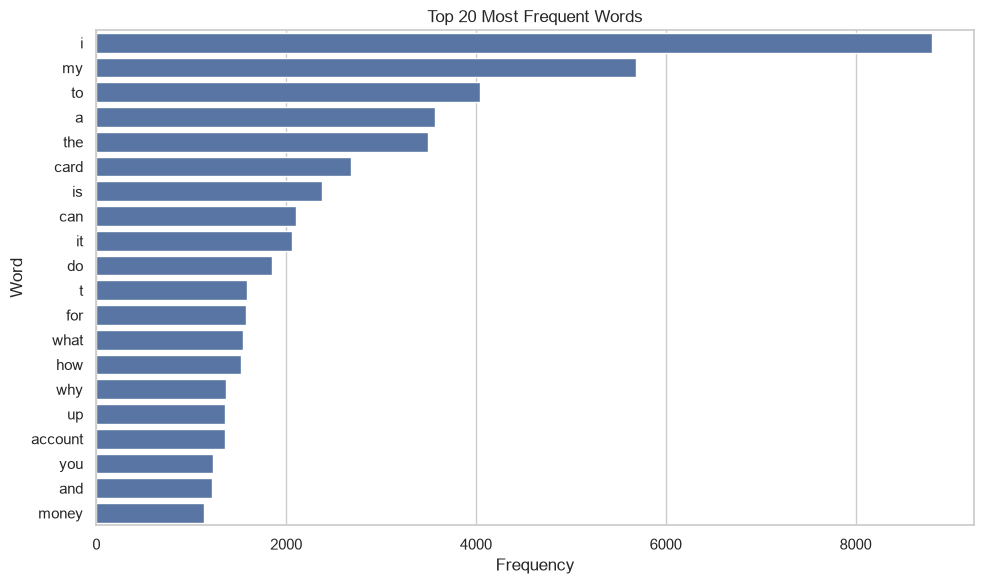

In [42]:
top_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["word", "count"]
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_words,
    x="count",
    y="word"
)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.tight_layout()
plt.show()

## 11. Data integrity after preprocessing

In [43]:
print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

print(
    "Training missing processed text:",
    train_df["processed_text"].isnull().sum()
)

print(
    "Testing missing processed text:",
    test_df["processed_text"].isnull().sum()
)

Training shape: (10003, 6)
Testing shape: (3080, 3)
Training missing processed text: 0
Testing missing processed text: 0


In [44]:
print(
    "Empty processed training texts:",
    (train_df["processed_text"].str.len() == 0).sum()
)

print(
    "Empty processed testing texts:",
    (test_df["processed_text"].str.len() == 0).sum()
)

Empty processed training texts: 0
Empty processed testing texts: 0


In [45]:
train_df.head()

,text,category,char_count,word_count,processed_text,processed_word_count
0,I am still waiting on my card?,card_arrival,30,7,i am still waiting on my card,7
1,What can I do if my card still hasn't arrived after 2 weeks?,card_arrival,60,13,what can i do if my card still hasn t arrived after weeks,13
2,I have been waiting over a week. Is the card still coming?,card_arrival,58,12,i have been waiting over a week is the card still coming,12
3,Can I track my card while it is in the process of delivery?,card_arrival,59,13,can i track my card while it is in the process of delivery,13
4,"How do I know if I will get my card, or if it is lost?",card_arrival,54,15,how do i know if i will get my card or if it is lost,15


In [46]:
train_processed = train_df[
    ["text", "processed_text", "category"]
].copy()

test_processed = test_df[
    ["text", "processed_text", "category"]
].copy()

In [47]:
os.makedirs("../data/processed", exist_ok=True)

train_processed.to_csv(
    "../data/processed/train.csv",
    index=False
)

test_processed.to_csv(
    "../data/processed/test.csv",
    index=False
)

## 12. Verify saved files

In [48]:
import os

print(
    "Train processed exists:",
    os.path.exists("../data/processed/train.csv")
)

print(
    "Test processed exists:",
    os.path.exists("../data/processed/test.csv")
)

Train processed exists: True
Test processed exists: True


In [49]:
train_check = pd.read_csv(
    "../data/processed/train.csv"
)

test_check = pd.read_csv(
    "../data/processed/test.csv"
)

In [50]:
print(train_check.shape)
print(test_check.shape)

train_check.head()

(10003, 3)
(3080, 3)


,text,processed_text,category
0,I am still waiting on my card?,i am still waiting on my card,card_arrival
1,What can I do if my card still hasn't arrived after 2 weeks?,what can i do if my card still hasn t arrived after weeks,card_arrival
2,I have been waiting over a week. Is the card still coming?,i have been waiting over a week is the card still coming,card_arrival
3,Can I track my card while it is in the process of delivery?,can i track my card while it is in the process of delivery,card_arrival
4,"How do I know if I will get my card, or if it is lost?",how do i know if i will get my card or if it is lost,card_arrival
